### fairness over time with machine-translated French CivilComments results
- en results: results_fairness_over_time/summary_all_models.csv
- fr results: results_fairness_over_time_fr_mt/summary_all_models.csv
- fairness summary column: avg_minmax_abs

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import spearmanr, pearsonr, linregress

In [2]:
# paths
EN_SUMMARY_CSV = "results_fairness_over_time/summary_all_models.csv"
FR_SUMMARY_CSV = "results_fairness_over_time_fr_mt/summary_all_models.csv"

PLOT_DIR = "results_fairness_over_time_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# which fairness summary to use
FAIRNESS_COL = "avg_minmax_abs"   # other possibilities "avg_minmax_rel" or "avg_var"
ACC_COL = "test_acc"

df_en = pd.read_csv(EN_SUMMARY_CSV).sort_values(["year", "model_id"]).reset_index(drop=True)
df_fr = pd.read_csv(FR_SUMMARY_CSV).sort_values(["year", "model_id"]).reset_index(drop=True)

# exclude the non-base models
exclude_models = [
    "LiquidAI/LFM2-2.6B",
    "Salesforce/xLAM-2-3b-fc-r",
]
exclude_models = [m.strip() for m in exclude_models]

df_en = df_en[~df_en["model_id"].isin(exclude_models)].copy()
df_fr = df_fr[~df_fr["model_id"].isin(exclude_models)].copy()

print("English shape:", df_en.shape)
print("French shape:", df_fr.shape)

print("\nEnglish columns:")
print(df_en.columns.tolist())

print("\nFrench columns:")
print(df_fr.columns.tolist())

English shape: (29, 26)
French shape: (28, 26)

English columns:
['year', 'model_id', 'batch_size', 'max_len', 'trust_remote_code', 'base_rate_cal', 'threshold_t', 'test_acc', 'test_pos_rate', 'test_fpr', 'test_fnr', 'acc_minmax_abs', 'acc_minmax_rel', 'acc_var', 'pos_rate_minmax_abs', 'pos_rate_minmax_rel', 'pos_rate_var', 'fpr_minmax_abs', 'fpr_minmax_rel', 'fpr_var', 'fnr_minmax_abs', 'fnr_minmax_rel', 'fnr_var', 'avg_minmax_abs', 'avg_minmax_rel', 'avg_var']

French columns:
['year', 'model_id', 'batch_size', 'max_len', 'trust_remote_code', 'base_rate_cal', 'threshold_t', 'test_acc', 'test_pos_rate', 'test_fpr', 'test_fnr', 'acc_minmax_abs', 'acc_minmax_rel', 'acc_var', 'pos_rate_minmax_abs', 'pos_rate_minmax_rel', 'pos_rate_var', 'fpr_minmax_abs', 'fpr_minmax_rel', 'fpr_var', 'fnr_minmax_abs', 'fnr_minmax_rel', 'fnr_var', 'avg_minmax_abs', 'avg_minmax_rel', 'avg_var']


In [3]:
# merge English and French on the same model-year pairs
df_compare = df_en.merge(
    df_fr,
    on=["year", "model_id"],
    suffixes=("_en", "_fr"),
    how="inner"
).sort_values(["year", "model_id"]).reset_index(drop=True)

# deltas
df_compare["delta_fairness"] = df_compare[f"{FAIRNESS_COL}_fr"] - df_compare[f"{FAIRNESS_COL}_en"]
df_compare["delta_acc"] = df_compare[f"{ACC_COL}_fr"] - df_compare[f"{ACC_COL}_en"]

print("Matched EN/FR rows:", len(df_compare))
df_compare[["year", "model_id", f"{FAIRNESS_COL}_en", f"{FAIRNESS_COL}_fr", "delta_fairness"]].head()

Matched EN/FR rows: 28


,year,model_id,avg_minmax_abs_en,avg_minmax_abs_fr,delta_fairness
0,2021,EleutherAI/gpt-neo-2.7B,0.161069,0.198847,0.037777
1,2021,facebook/xglm-2.9B,0.139984,0.210556,0.070571
2,2022,EleutherAI/pythia-2.8b-deduped-v0,0.175970,0.129880,-0.046089
3,2022,EleutherAI/pythia-2.8b-v0,0.281412,0.243998,-0.037414
4,2022,Salesforce/codegen-2B-multi,0.248553,0.214410,-0.034143


In [ ]:
# helper functions for plotting

def scatter_models_legend(
    df,
    xcol,
    ycol,
    title,
    xlabel,
    ylabel,
    x_is_year=False,
    add_line=True,
    line_type="year_mean",   
    corr_method="spearman", 
    show_stats=True,
    stats_loc="inside"     
):
    fig, ax = plt.subplots(figsize=(15, 6))

    # scatter points, one color per model
    for model_id, sub in df.groupby("model_id", sort=False):
        x = sub[xcol].astype(int) if x_is_year else sub[xcol].astype(float)
        y = sub[ycol].astype(float)
        ax.scatter(x, y, label=model_id)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if x_is_year:
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        years = sorted(df[xcol].dropna().astype(int).unique())
        ax.set_xticks(years)

    ax.grid(True, linewidth=0.5, alpha=0.5)

    # numeric data for line / correlation
    sub_num = df[[xcol, ycol]].dropna().copy()
    x_all = sub_num[xcol].astype(int).to_numpy() if x_is_year else sub_num[xcol].astype(float).to_numpy()
    y_all = sub_num[ycol].astype(float).to_numpy()

    # add line
    if add_line and len(sub_num) >= 2:
        if line_type == "year_mean" and x_is_year:
            mean_line = (
                sub_num.groupby(xcol, as_index=False)[ycol]
                .mean()
                .sort_values(xcol)
            )
            ax.plot(
                mean_line[xcol].astype(int),
                mean_line[ycol].astype(float),
                marker="o",
                linewidth=2,
                label="Year mean"
            )

        elif line_type == "fit":
            slope, intercept, _, _, _ = linregress(x_all, y_all)
            xs = np.linspace(x_all.min(), x_all.max(), 200)
            ys = intercept + slope * xs
            ax.plot(xs, ys, linestyle="--", linewidth=2, label="Linear fit")

    # correlation
    stats_text = None
    if show_stats and len(sub_num) >= 2:
        if corr_method == "spearman":
            rho, pval = spearmanr(x_all, y_all)
            stats_text = f"Spearman's $\\rho$ = {rho:.3f}\np = {pval:.4g}"
        elif corr_method == "pearson":
            rho, pval = pearsonr(x_all, y_all)
            stats_text = f"Pearson's $r$ = {rho:.3f}\np = {pval:.4g}"

    if stats_text is not None:
        if stats_loc == "inside":
            ax.text(
                0.02, 0.98,
                stats_text,
                transform=ax.transAxes,
                va="top",
                ha="left",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
            )
        elif stats_loc == "below":
            fig.text(0.12, 0.02, stats_text, ha="left", va="bottom", fontsize=10)

    n_models = df["model_id"].nunique()
    fontsize = 8 if n_models <= 20 else 6

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
        fontsize=fontsize
    )

    if stats_loc == "below":
        fig.tight_layout(rect=[0, 0.08, 0.75, 1])
    else:
        fig.tight_layout(rect=[0, 0, 0.75, 1])

    plt.show()



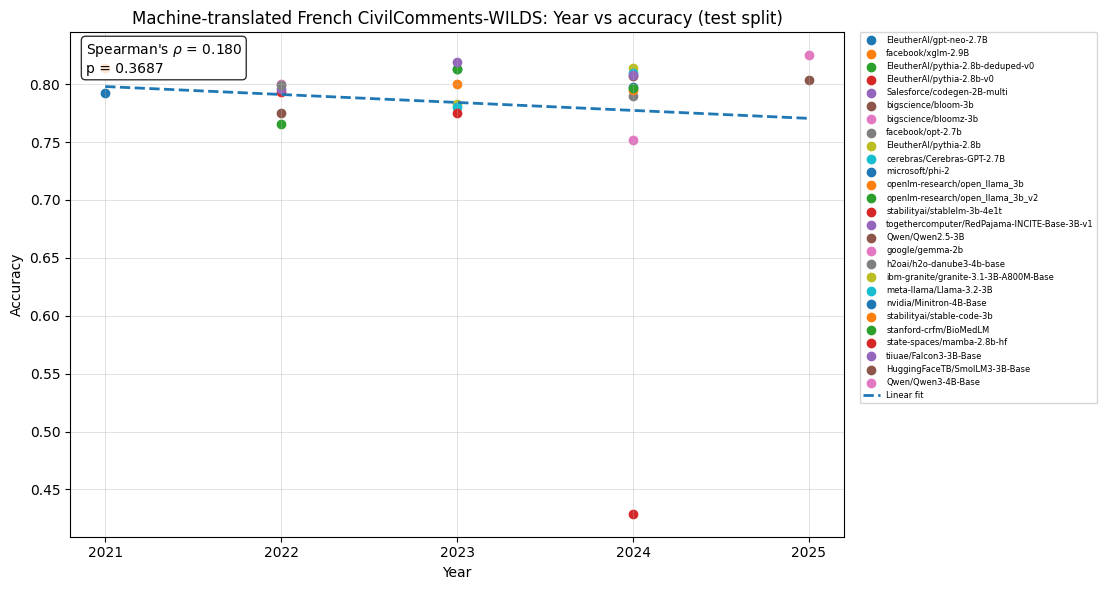

In [ ]:
# french: year vs accuracy

bad_model = "google/recurrentgemma-2b"

df_fr = df_fr[df_fr["model_id"] != bad_model].copy()
df_compare = df_compare[df_compare["model_id"] != bad_model].copy()

scatter_models_legend(df_fr, "year", "test_acc",
                      "Machine-translated French CivilComments-WILDS: Year vs accuracy (test split)",
                      "Year", "Accuracy",
                      x_is_year=True, add_line=True, line_type="fit", corr_method="spearman", show_stats=True, stats_loc="inside")

With outlier: 27
Without outlier: 26

Removed row:


,year,model_id,avg_minmax_abs,test_acc
24,2024,state-spaces/mamba-2.8b-hf,0.388197,0.429


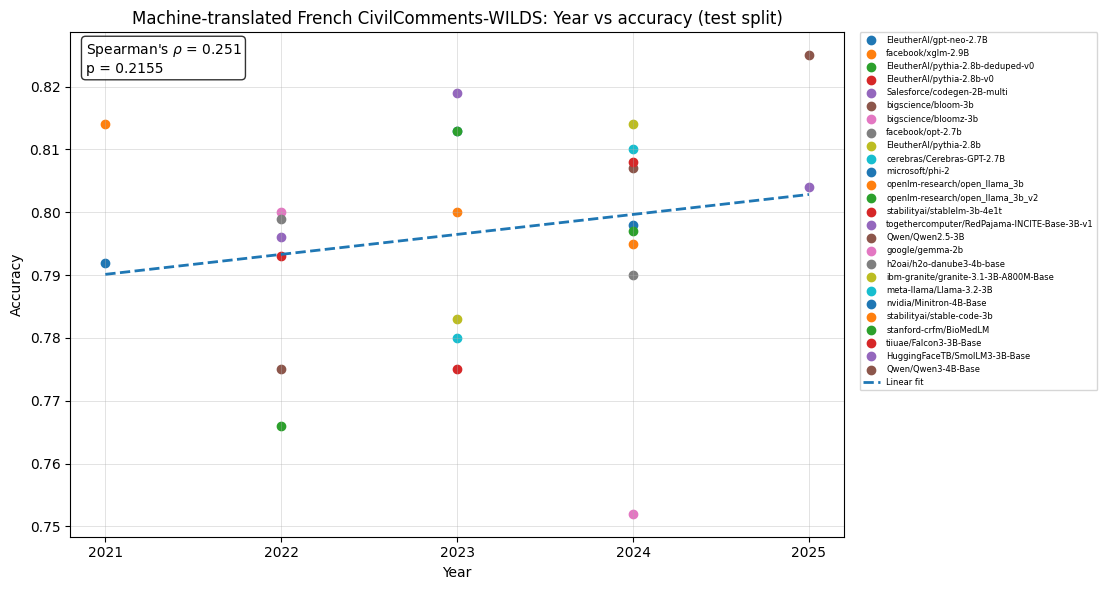

In [6]:
# without the outlier

fairness_outlier_model = "state-spaces/mamba-2.8b-hf"

df_fr_no_outlier = df_fr[df_fr["model_id"] != fairness_outlier_model].copy()

print("With outlier:", len(df_fr))
print("Without outlier:", len(df_fr_no_outlier))
print("\nRemoved row:")
display(
    df_fr[df_fr["model_id"] == fairness_outlier_model][
        ["year", "model_id", FAIRNESS_COL, "test_acc"]
    ]
)

# plot without the outlier
scatter_models_legend(
    df_fr_no_outlier, "year", "test_acc",
    "Machine-translated French CivilComments-WILDS: Year vs accuracy (test split)",
    "Year", "Accuracy",
    x_is_year=True, add_line=True, line_type="fit",
    corr_method="spearman", show_stats=True, stats_loc="inside"
)

In [7]:
# there is an outlier, with less than 0.5 accuracy, and also a model with an accuracy that could seem like it just classifies everything as non-toxic
# biggest fairness values in French
df_fr.nlargest(30, FAIRNESS_COL)[
    ["year", "model_id", FAIRNESS_COL, "test_acc"]
]

,year,model_id,avg_minmax_abs,test_acc
24,2024,state-spaces/mamba-2.8b-hf,0.388197,0.429
23,2024,stanford-crfm/BioMedLM,0.286333,0.797
28,2025,Qwen/Qwen3-4B-Base,0.250617,0.825
14,2023,togethercomputer/RedPajama-INCITE-Base-3B-v1,0.250038,0.819
3,2022,EleutherAI/pythia-2.8b-v0,0.243998,0.793
21,2024,nvidia/Minitron-4B-Base,0.237950,0.798
10,2023,microsoft/phi-2,0.236343,0.813
13,2023,stabilityai/stablelm-3b-4e1t,0.228438,0.775
26,2025,HuggingFaceTB/SmolLM3-3B-Base,0.221689,0.804
18,2024,h2oai/h2o-danube3-4b-base,0.221295,0.790


In [8]:
# state-spaces/mamba-2.8b-hf has very low accuracy, lets inspect it
bad_model = "state-spaces/mamba-2.8b-hf"

df_fr[df_fr["model_id"] == bad_model][
    ["year", "model_id", "test_acc", "avg_minmax_abs",
     "acc_minmax_abs", "pos_rate_minmax_abs", "fpr_minmax_abs", "fnr_minmax_abs"]
].sort_values("year")

,year,model_id,test_acc,avg_minmax_abs,acc_minmax_abs,pos_rate_minmax_abs,fpr_minmax_abs,fnr_minmax_abs
24,2024,state-spaces/mamba-2.8b-hf,0.429,0.388197,0.19845,0.402066,0.364035,0.588235


In [9]:
df_compare[df_compare["model_id"] == bad_model][
    ["year", "model_id",
     "test_acc_en", "test_acc_fr", "delta_acc",
     "avg_minmax_abs_en", "avg_minmax_abs_fr", "delta_fairness"]
].sort_values("year")

,year,model_id,test_acc_en,test_acc_fr,delta_acc,avg_minmax_abs_en,avg_minmax_abs_fr,delta_fairness
24,2024,state-spaces/mamba-2.8b-hf,0.813,0.429,-0.384,0.19333,0.388197,0.194867


the accuracy outlier is "state-spaces/mamba-2.8b-hf". After inspecting it some more, it seems that the outlier is not just a fairness issue in isolation. It is mainly caused by the model performing very poorly overall on the translated French data, and this poor overall performance then produces large disparities across groups <br><br>
Inspection of the outlier shows that it is primarily driven by very poor French performance for state-spaces/mamba-2.8b-hf, rather than by a small fairness-specific deviation. In particular, the model’s test accuracy drops from 0.813 to 0.429, while its fairness gap increases from 0.193 to 0.388. The French fairness score is especially driven by a large false negative rate disparity (0.588), indicating that the model behaves highly unevenly across identity groups once translated.

In [10]:
# google/recurrentgemma-2b has very high accuracy, so we should also inspect it
# df_fr[df_fr["model_id"] == "google/recurrentgemma-2b"][
#     ["year", "model_id", "test_acc",
#      "avg_minmax_abs",
#      "acc_minmax_abs", "pos_rate_minmax_abs",
#      "fpr_minmax_abs", "fnr_minmax_abs"]
# ]

# bad_model = "google/recurrentgemma-2b"

# df_fr[df_fr["model_id"] == bad_model][
#     ["year", "group", "acc", "pos_rate", "fpr", "fnr"]
# ].sort_values("group")

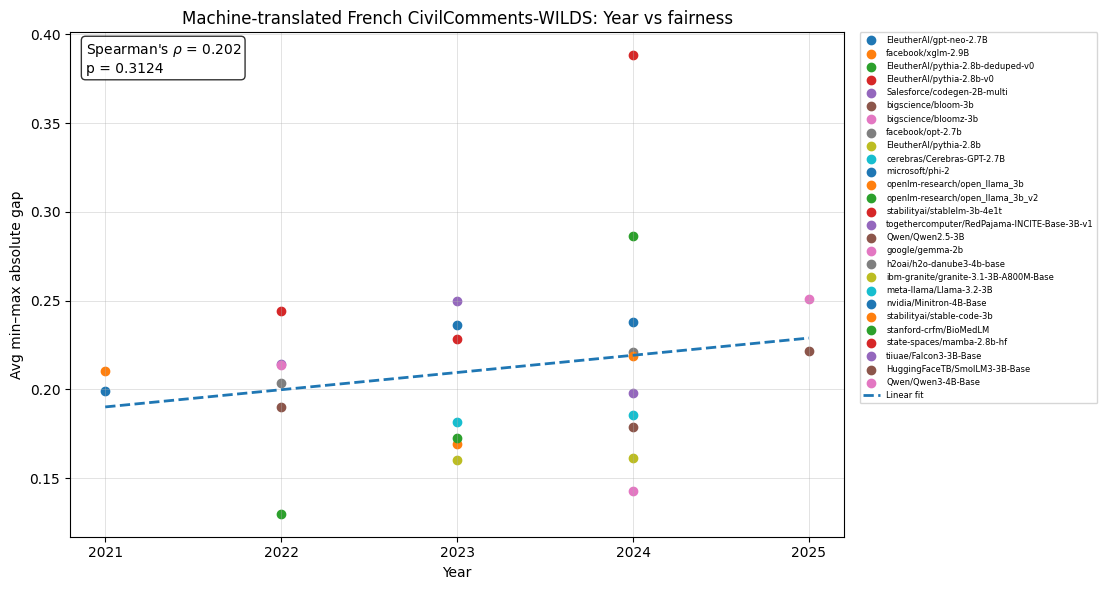

In [ ]:
# french: year vs fairness
scatter_models_legend(df_fr, "year", FAIRNESS_COL,
                      "Machine-translated French CivilComments-WILDS: Year vs fairness",
                      "Year", "Avg min–max absolute gap",
                      x_is_year=True, add_line=True, line_type="fit", corr_method="spearman", show_stats=True, stats_loc="inside")

With outlier: 27
Without outlier: 26

Removed row:


,year,model_id,avg_minmax_abs,test_acc
24,2024,state-spaces/mamba-2.8b-hf,0.388197,0.429


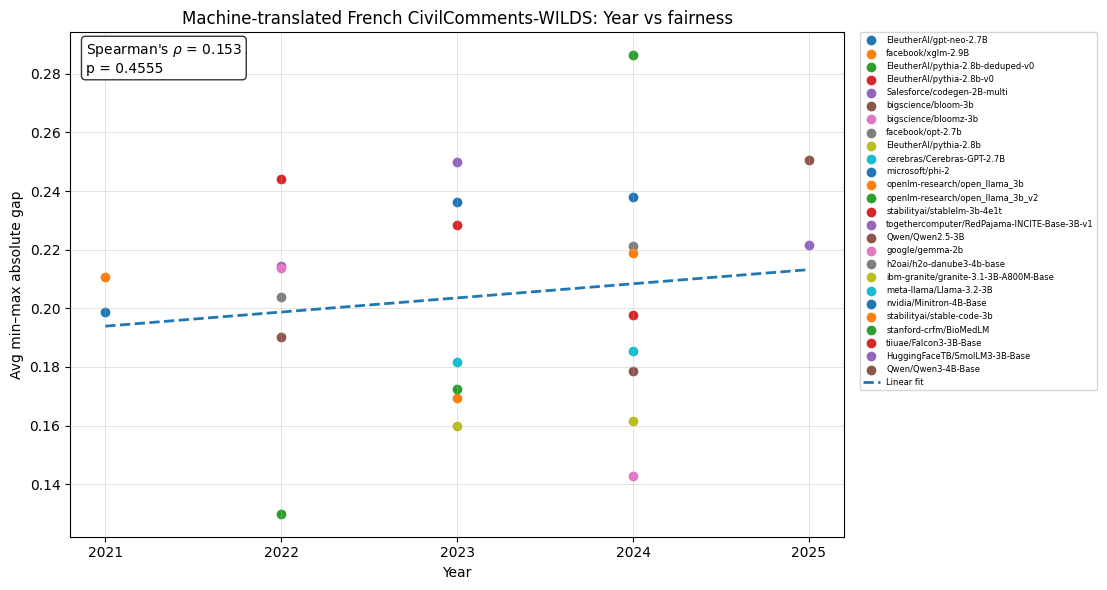

In [12]:
# without the outlier

fairness_outlier_model = "state-spaces/mamba-2.8b-hf"

df_fr_no_outlier = df_fr[df_fr["model_id"] != fairness_outlier_model].copy()

print("With outlier:", len(df_fr))
print("Without outlier:", len(df_fr_no_outlier))
print("\nRemoved row:")
display(
    df_fr[df_fr["model_id"] == fairness_outlier_model][
        ["year", "model_id", FAIRNESS_COL, "test_acc"]
    ]
)

# # original plot
# scatter_models_legend(
#     df_fr, "year", FAIRNESS_COL,
#     "Machine-translated French CivilComments-WILDS: Year vs fairness (with outlier)",
#     "Year", "Avg min–max absolute gap",
#     x_is_year=True, add_line=True, line_type="fit",
#     corr_method="spearman", show_stats=True, stats_loc="inside"
# )

# plot without the outlier
scatter_models_legend(
    df_fr_no_outlier, "year", FAIRNESS_COL,
    "Machine-translated French CivilComments-WILDS: Year vs fairness",
    "Year", "Avg min–max absolute gap",
    x_is_year=True, add_line=True, line_type="fit",
    corr_method="spearman", show_stats=True, stats_loc="inside"
)

In [ ]:
# helper: scatter comparing English vs French

def plot_compare_scatter(
    df,
    col_en,
    col_fr,
    xlabel,
    ylabel,
    title,
    corr_method="spearman",   
    show_stats=True
):
    fig, ax = plt.subplots(figsize=(6, 6))

    sub = df[[col_en, col_fr]].dropna().copy()
    x = sub[col_en].to_numpy()
    y = sub[col_fr].to_numpy()

    ax.scatter(x, y, alpha=0.75)

    # diagonal reference line
    lo = min(np.nanmin(x), np.nanmin(y))
    hi = max(np.nanmax(x), np.nanmax(y))
    ax.plot([lo, hi], [lo, hi], linestyle="--")

    # correlation + p-value
    if corr_method == "spearman":
        rho, pval = spearmanr(x, y)
        stats_text = f"Spearman's $\\rho$ = {rho:.3f}\np = {pval:.4g}"
    elif corr_method == "pearson":
        rho, pval = pearsonr(x, y)
        stats_text = f"Pearson's $r$ = {rho:.3f}\np = {pval:.4g}"
    else:
        raise ValueError("corr_method must be 'spearman' or 'pearson'")

    if show_stats:
        ax.text(
            0.02, 0.98,
            stats_text,
            transform=ax.transAxes,
            va="top",
            ha="left",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()


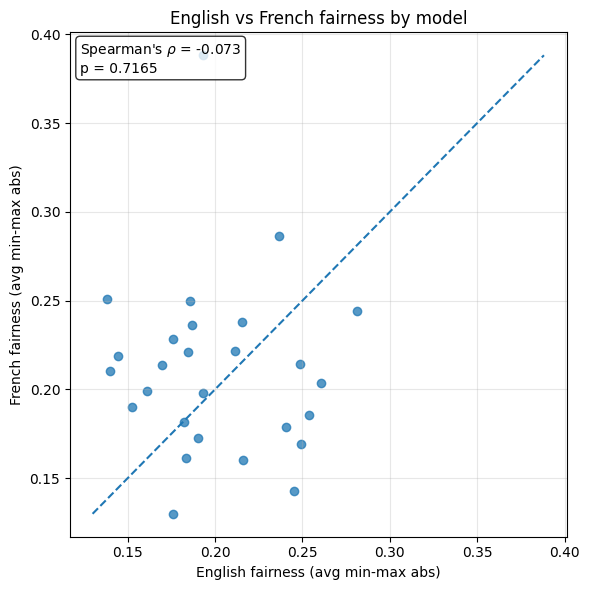

In [ ]:
# english vs French fairness scatter
# do models that are more fair in English also tend to be more fair in French?
plot_compare_scatter(
    df_compare,
    col_en=f"{FAIRNESS_COL}_en",
    col_fr=f"{FAIRNESS_COL}_fr",
    xlabel="English fairness (avg min-max abs)",
    ylabel="French fairness (avg min-max abs)",
    title="English vs French fairness by model"
)

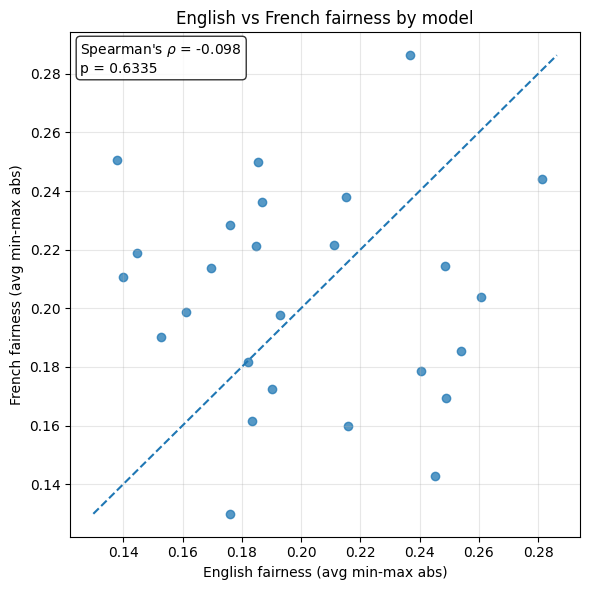

In [15]:
# without outlier
df_compare_no_outlier = df_compare[df_compare["model_id"] != fairness_outlier_model].copy()

plot_compare_scatter(
    df_compare_no_outlier,
    col_en=f"{FAIRNESS_COL}_en",
    col_fr=f"{FAIRNESS_COL}_fr",
    xlabel="English fairness (avg min-max abs)",
    ylabel="French fairness (avg min-max abs)",
    title="English vs French fairness by model"
)

In [16]:
# helper: paired plot for English vs French fairness within each year
def plot_paired_fairness_by_year(df):
    years = sorted(df["year"].unique())

    for year in years:
        d = df[df["year"] == year].sort_values("model_id").reset_index(drop=True)

        plt.figure(figsize=(8, max(4, 0.28 * len(d))))

        y_pos = np.arange(len(d))
        x_en = d[f"{FAIRNESS_COL}_en"].to_numpy()
        x_fr = d[f"{FAIRNESS_COL}_fr"].to_numpy()

        for i in range(len(d)):
            plt.plot([x_en[i], x_fr[i]], [y_pos[i], y_pos[i]], alpha=0.6)
            plt.scatter(x_en[i], y_pos[i], alpha=0.9, label="English" if i == 0 else None)
            plt.scatter(x_fr[i], y_pos[i], alpha=0.9, label="French" if i == 0 else None)

        plt.yticks(y_pos, d["model_id"])
        plt.xlabel("Fairness summary (avg min-max abs)")
        plt.title(f"English vs French fairness, {year}")
        plt.grid(True, axis="x", alpha=0.3)
        plt.legend()
        plt.tight_layout()


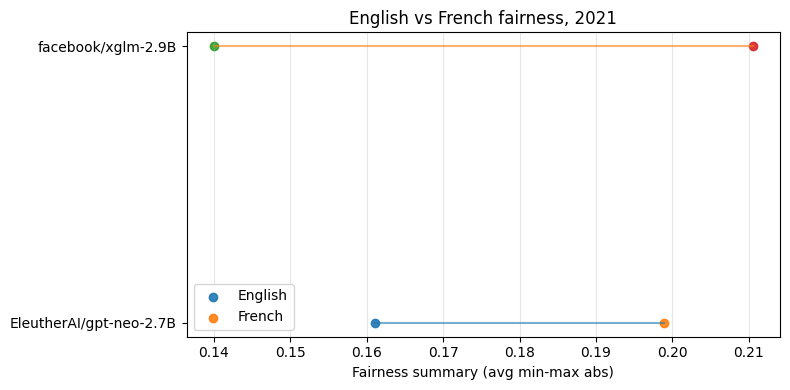

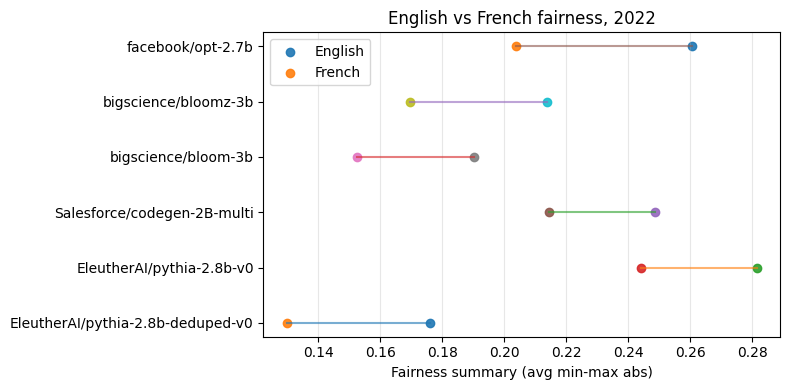

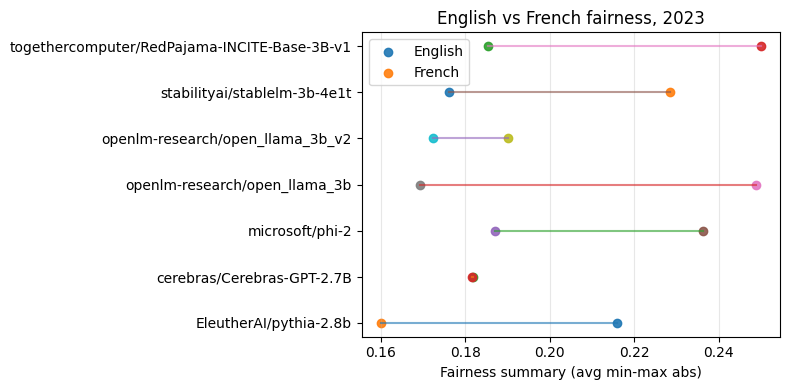

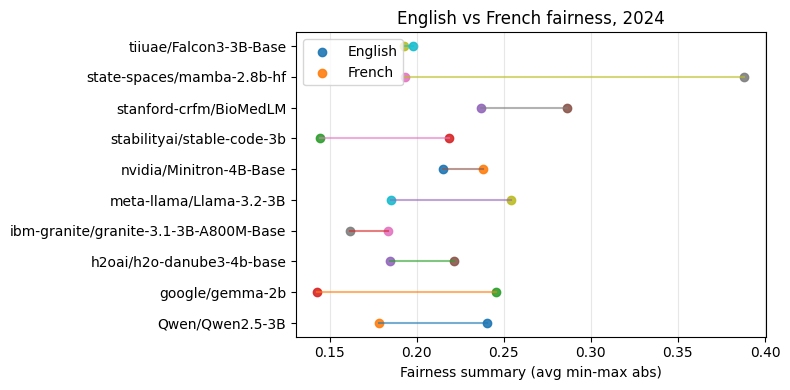

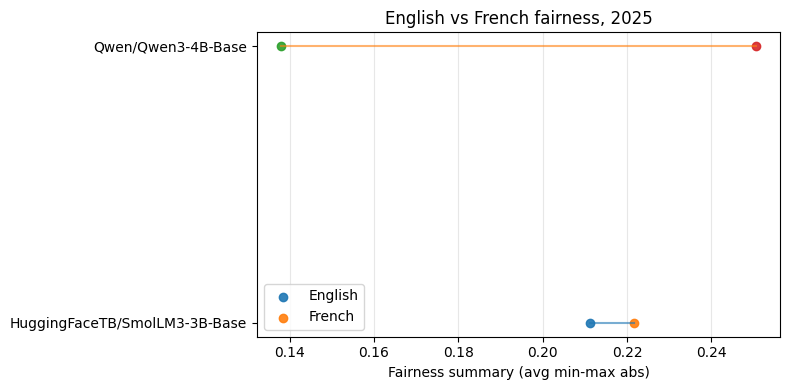

In [ ]:
# paired English vs French fairness for each year
plot_paired_fairness_by_year(df_compare)

In [18]:
# helper: delta fairness by year
def plot_delta_by_year(df, delta_col, ylabel, title):
    plt.figure(figsize=(8, 5))

    rng = np.random.default_rng(42)
    x_jitter = df["year"].astype(float).to_numpy() + rng.uniform(-0.12, 0.12, size=len(df))
    plt.scatter(x_jitter, df[delta_col], alpha=0.7)

    ys = yearly_summary(df, delta_col)
    plt.plot(ys["year"], ys["mean"], marker="o")

    plt.axhline(0.0, linestyle="--")
    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

In [ ]:
# # delta fairness by year: French - English
# plot_delta_by_year(
#     df_compare,
#     delta_col="delta_fairness",
#     ylabel="Delta fairness (French - English)",
#     title="Change in fairness under French translation"
# )

In [20]:
# # summary tables
# yearly_fr_fairness = yearly_summary(df_fr, FAIRNESS_COL)
# yearly_fr_acc = yearly_summary(df_fr, ACC_COL)
# yearly_delta = yearly_summary(df_compare, "delta_fairness")

# print("French fairness by year")
# display(yearly_fr_fairness)

# print("French accuracy by year")
# display(yearly_fr_acc)

# print("Delta fairness (French - English) by year")
# display(yearly_delta)